# Uber Rides Analysis

This comprehensive dataset contains detailed ride-sharing data from Uber operations for the year 2024, providing rich insights into booking patterns, vehicle performance, revenue streams, cancellation behaviors, and customer satisfaction metrics. The dataset captures 150,000 total bookings across multiple vehicle types and provides a complete view of ride-sharing operations including successful rides, cancellations, customer behaviors, and financial metrics.

The dataset was cleaned and preprocessed for ease of analysis and is available under an open license for research and data analysis purposes. The dataset is provided by a user from Kaggle (https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard). We will be using Python to analyze the dataset and a series of visualisations such as pandas, seaborn, matplotlib and SciPy libraries to answer the following questions:

1. What are the main reasons for driver and customer cancellations?
2. When are the yearly and daily peak times? How does seasonality affect booking demand?
3. How do the various vehicle types differ from each other?
4. How does each factor affect the booking fare?
5. What differs between the top 10% and bottom 10% of Uber ride fares?

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import textwrap
from matplotlib import pyplot as plt
import warnings
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
warnings.simplefilter(action='ignore', category=FutureWarning)

## Inspect Data

In [3]:
df = pd.read_csv('ncr_ride_bookings.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


This dataset contains 150000 entries with 20 different columns. However, 13 of these columns have null values. 

Here's a summary of the table.

- **Date**:	Date of the booking
- **Time**:	Time of the booking
- **Booking ID**:	Unique identifier for each ride booking
- **Booking Status**:	Status of booking (Completed, Cancelled by Customer, Cancelled by Driver, etc.)
- **Customer ID**:	Unique identifier for customers
- **Vehicle Type**:	Type of vehicle (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan)
- **Pickup Location**:	Starting location of the ride
- **Drop Location**:	Destination location of the ride
- **Avg VTAT**:	Average time for driver to reach pickup location (in minutes)
- **Avg CTAT**:	Average trip duration from pickup to destination (in minutes)
- **Cancelled Rides by Customer**:	Customer-initiated cancellation flag
- **Reason for cancelling by Customer**:	Reason for customer cancellation
- **Cancelled Rides by Driver**:	Driver-initiated cancellation flag
- **Driver Cancellation Reason**:	Reason for driver cancellation
- **Incomplete Rides**:	Incomplete ride flag
- **Incomplete Rides Reason**: Reason for incomplete rides
- **Booking Value**:	Total fare amount for the ride
- **Ride Distance**:	Distance covered during the ride (in km)
- **Driver Ratings**:	Rating given to driver (1-5 scale)
- **Customer Rating**:	Rating given by customer (1-5 scale)
- **Payment Method**:	Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card)

## Data Cleaning and Preparation

In [4]:
# Changing data type 
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['Date'] = pd.to_datetime(df['Date'], format = '%Y-%m-%d')
df['Time'] = pd.to_datetime(df['Time'], format = "%H:%M:%S")
df['Booking Status'] = df['Booking Status'].astype('category')
df['Vehicle Type'] = df['Vehicle Type'].astype('category')
df['Payment Method'] = df['Payment Method'].astype('category')

# Removing unnecessary string
df['Booking ID'] = df['Booking ID'].str.replace('"', '')
df['Customer ID'] = df['Customer ID'].str.replace('"', '')

# Filling null values with mode value
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])
df['Vehicle Type'] = df['Vehicle Type'].fillna(df['Vehicle Type'].mode()[0])

# Backfilling null values
null_cols = ['Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Avg VTAT', 'Avg CTAT']
for col in null_cols:
    df[col].fillna(method="bfill", inplace=True)

## Feature Engineering 

In [5]:
# Creating new columns for year, month, weekday and hour
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.day_name()
df['hour'] = df['datetime'].dt.hour

In [6]:
# Mapping months to season
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

# Map months to seasons
df["season"] = df["month"].map(season_map)

In [7]:
# Distance bins
distance_bin = [0,10,20,30,40,51]
df['distances'] = pd.cut(df['Ride Distance'], bins=distance_bin, 
                              labels=['0-10','10-20','20-30','30-40','40-50'])

# Driver rating bins
driver_rating_bin = [2.9,3.5,4,4.5,5.1]
df['driver_rating_bin'] = pd.cut(df['Driver Ratings'], bins=driver_rating_bin, 
                              labels=['3-3.5', '3.5-4', '4-4.5', '4.5-5'])

In [8]:
# Log Fare 
df['log_fare'] = np.log(df['Booking Value'])

## Exploratory Data Analysis

### Data Question 1: What are the main reasons for driver and customer cancellation?

In [9]:
# Booking status percentage
df['Booking Status'].value_counts(normalize = True).reset_index(name = 'Percentage')

,Booking Status,Percentage
0,Completed,0.62
1,Cancelled by Driver,0.18
2,Cancelled by Customer,0.07
3,No Driver Found,0.07
4,Incomplete,0.06


62% of Uber rides were completed while 18% of rides were cancelled by the driver. The remaining rides were either cancelled by the customer or unable to find a driver or were just incomplete due to other issues.

In [10]:
# Cancellations initial count
driver_cancel = df['Driver Cancellation Reason'].value_counts().reset_index(name='Count')
customer_cancel = df['Reason for cancelling by Customer'].value_counts().reset_index(name='Count')
incomplete_ride = df['Incomplete Rides Reason'].value_counts().reset_index(name='Count')

# Wrapping labels into multiple lines
def wrap_labels(labels, width=12):
    return ['\n'.join(textwrap.wrap(l, width)) for l in labels]

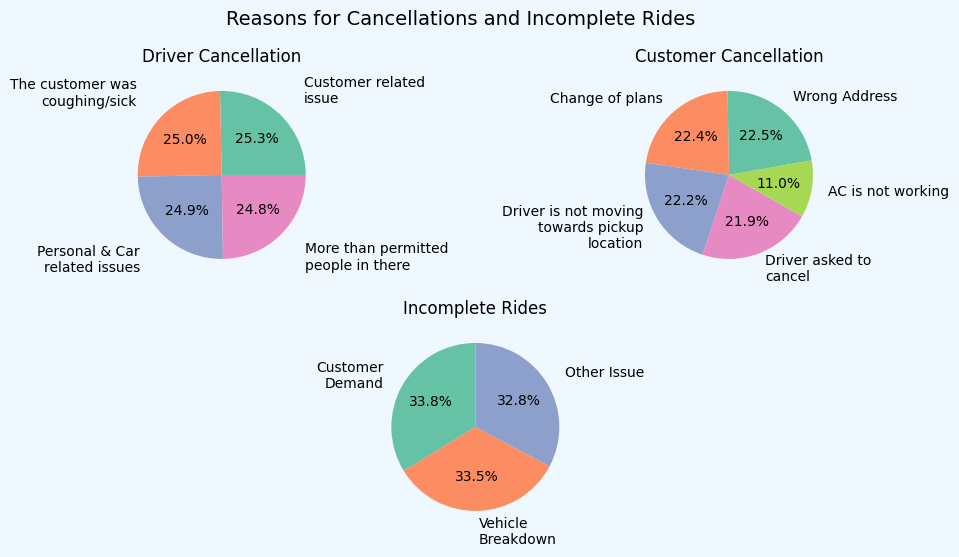

In [11]:
# Plotting pie chart of cancellation reasons
fig = plt.figure(figsize=(12, 6), facecolor = 'aliceblue')
plt.suptitle('Reasons for Cancellations and Incomplete Rides', fontsize = 14)
gs = fig.add_gridspec(2, 2)

# Driver cancellation reasons
ax1 = fig.add_subplot(gs[0, 0])
labels = wrap_labels(driver_cancel['Driver Cancellation Reason'], 20)
ax1.pie(driver_cancel['Count'], labels=labels, autopct='%1.1f%%', colors=sns.color_palette("Set2", 4), labeldistance = 1.4)
ax1.set_title('Driver Cancellation')

# Customer cancellation reasons
ax2 = fig.add_subplot(gs[0, 1])
labels = wrap_labels(customer_cancel['Reason for cancelling by Customer'], 20)
ax2.pie(customer_cancel['Count'], labels=labels, autopct='%1.1f%%', colors=sns.color_palette("Set2", 5), labeldistance = 1.2, startangle = 10)
ax2.set_title('Customer Cancellation')

# Incomplete rides reason
ax3 = fig.add_subplot(gs[1, :])  # span across all columns in row 1
labels = wrap_labels(incomplete_ride['Incomplete Rides Reason'], 12)
ax3.pie(incomplete_ride['Count'], labels=labels, autopct='%1.1f%%', colors=sns.color_palette("Set2", 3), labeldistance = 1.25, startangle = 90)
ax3.set_title('Incomplete Rides')

plt.show()

The reason for driver cancellations is split nearly equally into 4 reasons; unwell customer, customer related issue, personal and car related issue and exceeding number of passengers. For customer cancellation, the most common is due to the customer entering a wrong address or the customer had a change of plans.

### Data Question 2: When are the yearly and daily peak times? How does seasonality affect booking demand?

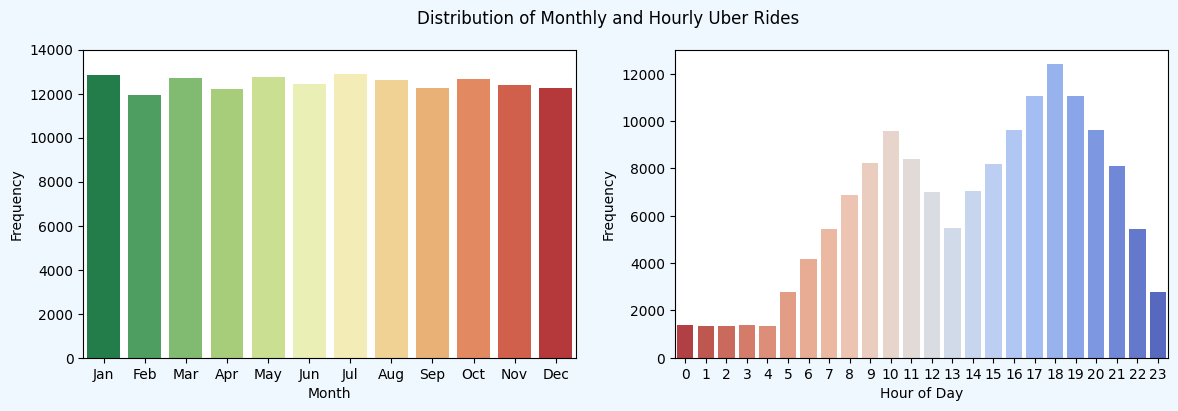

In [230]:
# Plotting figure for uber rides
plt.figure(figsize = (14,4), facecolor = 'aliceblue')
plt.suptitle('Distribution of Monthly and Hourly Uber Rides')

# Distribution
plt.subplot(1,2,1)
sns.countplot(data = df, x= 'month', palette = 'RdYlGn_r')
plt.xticks(ticks = np.arange(12), labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Frequency')
plt.xlabel('Month')
plt.ylim(0, 14000)

# Fare of Uber rides
plt.subplot(1,2,2)
sns.countplot(data = df, x = 'hour', palette = 'coolwarm_r')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.show()

The frequency of Uber rides is in the range of approximately 11900 to 13000 rides per month. January and July seem to have the highest frequency of Uber rides whereas February has the lowest frequency. According to the boxplot, March has the highest maximum booking fare of approximately 1430 rupees and the largest distribution. The distribution of customers by hour has two peaks. The number of customers initially increases from 5am to 10am, then dips down until 1pm and peaks again until 6pm. This could be due to the surge of customers before and after working hours. 

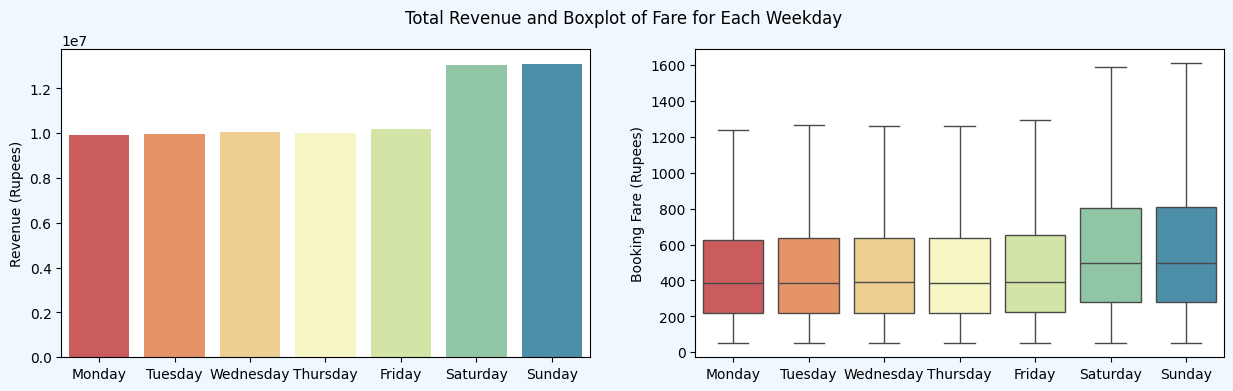

In [14]:
# Plotting figure 
plt.figure(figsize = (15,4), facecolor = 'aliceblue')
plt.suptitle('Total Revenue and Boxplot of Fare for Each Weekday')

# Total Revenue
plt.subplot(1,2,1)
sns.barplot(data = df, x = 'weekday', y = 'Booking Value', order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
           estimator = np.sum, ci = None, palette = 'Spectral')
plt.ylabel('Revenue (Rupees)')
plt.xlabel('')

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(data = df, x = 'weekday', y = 'Booking Value', showfliers = None, palette = 'Spectral', order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.ylabel('Booking Fare (Rupees)')
plt.xlabel('')
plt.show()

The total revenue on the weekends is much higher than weekdays, 30% higher. On the weekends, the total revenue is approximately 13 million each and for weekdays, it is only around 10 million rupees. The median fare on weekdays is approximately 390 rupees and on weekends, it is around 500 rupees. The distribution and maximum fare is also higher on Sat and Sunday.

In [15]:
# Performing pairwise comparisons with different seasons
new_df = df[df['log_fare'].notnull()]
tukey_oneway = pairwise_tukeyhsd(endog = new_df['log_fare'], groups = new_df['season'])
tukey_oneway.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Autumn,Spring,-0.0025,0.973,-0.0171,0.0122,False
Autumn,Summer,-0.0045,0.8576,-0.0191,0.0101,False
Autumn,Winter,-0.0029,0.9557,-0.0176,0.0118,False
Spring,Summer,-0.002,0.9839,-0.0166,0.0125,False
Spring,Winter,-0.0005,0.9998,-0.0151,0.0142,False
Summer,Winter,0.0016,0.9927,-0.0131,0.0162,False


The results above show that there is no significant difference in fare price among each season. 

### Data Question 3: How do the various vehicle types differ from each other?

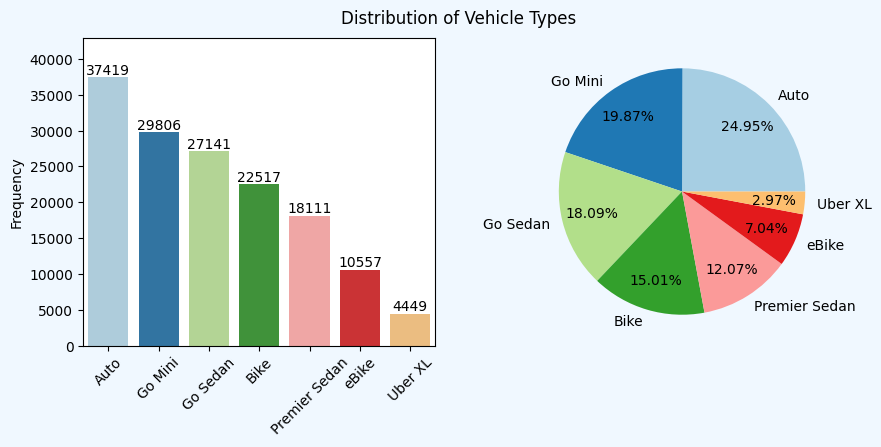

In [16]:
# Vehicle type count
vehicle = df['Vehicle Type'].value_counts().reset_index(name = 'Count')

# Plotting figure of vehicle type distribution 
plt.figure(figsize = (10,4), facecolor = 'aliceblue')
plt.suptitle('Distribution of Vehicle Types', y = .95)

# Countplot
plt.subplot(1,2,2)
plt.pie(data = vehicle, x = 'Count', labels = 'Vehicle Type', autopct = '%1.2f%%', colors = sns.color_palette("Paired", 8),
       pctdistance = 0.75)

# Pie chart
plt.subplot(1,2,1)
ax = sns.countplot(data = df, x = 'Vehicle Type', palette = 'Paired', 
                   order = ['Auto', 'Go Mini', 'Go Sedan', 'Bike', 'Premier Sedan', 'eBike', 'Uber XL'])
plt.xticks(rotation = 45)
plt.xlabel('')
plt.ylim(0, 43000)
plt.ylabel('Frequency')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
plt.show()

Generally, automobiles are the most common vehicle for Uber rides, accounting for 25% of all rides. Go Mini and Go Sedan are also quite popular, accounting for 20% and 18% respectively. The least popular vehicle type is Uber XL, consisting only 3% of rides. 

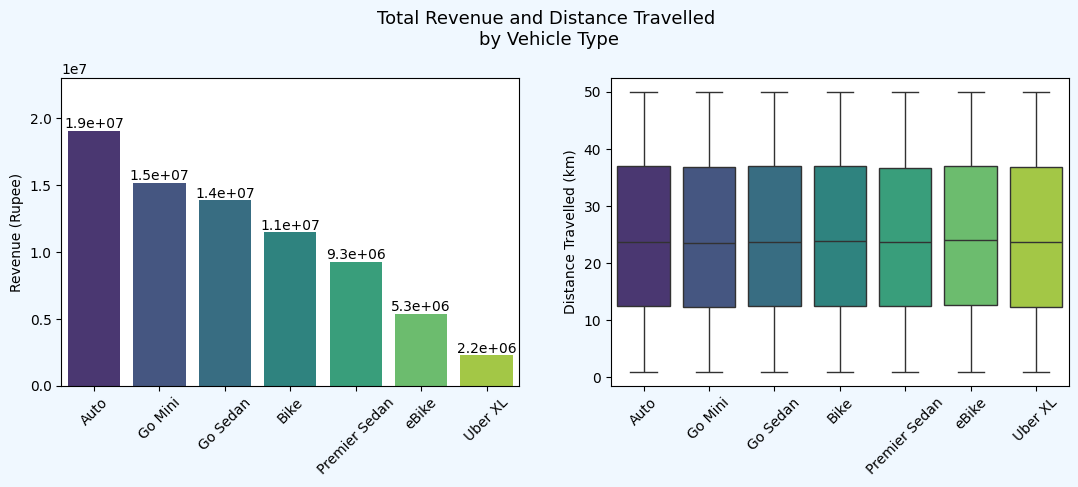

In [17]:
# Plotting figure of total revenue and distance by vehicle type
plt.figure(figsize = (13,4), facecolor = 'aliceblue')
plt.subplots_adjust(wspace = 0.2)
plt.suptitle('Total Revenue and Distance Travelled \nby Vehicle Type', y = 1.05, fontsize = 13)

# Revenue
plt.subplot(1,2,1)
ax = sns.barplot(data = df, x = 'Vehicle Type',  y = 'Booking Value', palette = 'viridis', estimator = np.sum, 
            order = ['Auto', 'Go Mini', 'Go Sedan', 'Bike', 'Premier Sedan', 'eBike', 'Uber XL'], ci = None)
plt.xticks(rotation = 45)
plt.xlabel('')
plt.ylabel('Revenue (Rupee)')
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt = '%2.1e')
plt.ylim(0, 2.3e7)

# Distance
plt.subplot(1,2,2)
sns.boxplot(data = df, x = 'Vehicle Type', y = 'Ride Distance', palette = 'viridis', 
            order = ['Auto', 'Go Mini', 'Go Sedan', 'Bike', 'Premier Sedan', 'eBike', 'Uber XL'])
plt.xlabel('')
plt.ylabel('Distance Travelled (km)')
plt.xticks(rotation = 45)
plt.show()

The revenue for each vehicle type follows the trend of its distribution. Automobiles have the highest total revenue of 19 million rupees, followed by Go Mini and Go Sedan with 15 million and 14 million rupees respectively. The distance travelled for each vehicle is almost the same; median of 24km, minimum of 1km and maximum of 50km. 

In [18]:
# OLS
ols_formula = "log_fare ~ C(Q('Vehicle Type'))"
model = ols(formula = ols_formula, data = df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_fare   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4155
Date:                Thu, 02 Oct 2025   Prob (F-statistic):              0.869
Time:                        14:46:45   Log-Likelihood:            -1.7549e+05
No. Observations:              150000   AIC:                         3.510e+05
Df Residuals:                  149993   BIC:                         3.511e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 5.9528      0.004   1477.108      0.000       5.945       5.961
C(Q('Vehicle Type'))[T.Bike]          -9.749e-05      0.007     -0.015      0.988      -0.013       0.013
C(Q('Vehicle Type'))[T.Go Mini]          -0.0011      0.006     -0.189      0.850      -0.013       0.011
C(Q('Vehicle Type'))[T.Go Sedan]          0.0032      0.006      0.518      0.605      -0.009       0.015
C(Q('Vehicle Type'))[T.Premier Sedan]     0.0068      0.007      0.970      0.332      -0.007       0.021
C(Q('Vehicle Type'))[T.Uber XL]          -0.0003      0.012     -0.023      0.982      -0.025       0.024
C(Q('Vehicle Type'))[T.eBike]            -0.0063      0.009     -0.736      0.462      -0.023       0.011
==============================================================================
Omnibus:                     2880.873   Durbin-Watson:                   1.365
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2907.675
Skew:                          -0.321   Prob(JB):                         0.00
Kurtosis:                       2.769   Cond. No.                         7.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Since the p-value is higher than the significance threshold (0.05), we can accept the null hypothesis which states that the booking fare for each vehicle is the same and there is no signifcant difference.

### Data Question 4: How does each factor affect the booking fare?

In [20]:
# DataFrame with dropped columns
df2 = df.drop(columns = {'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 
                        'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Date', 'Time', 'Booking ID', 'Customer ID', 
                        'datetime', 'log_fare', 'Pickup Location', 'Drop Location', 'driver_rating_bin', 'distances'})

In [21]:
# Creating correlation matrix
corr_matrix = df[['Avg CTAT', 'Avg VTAT', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Booking Value', 
                  'month', 'hour', 'Driver Ratings', 'Customer Rating']].corr(method = 'pearson')

# Plotting heatmap between independent and dependent variable
corr_target = corr_matrix[['Booking Value']].drop(labels = 'Booking Value')

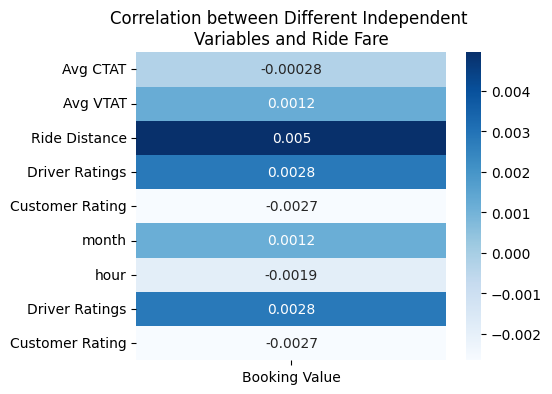

In [22]:
# Plotting heatmap for correlation between variables
plt.figure(figsize = (5,4))
sns.heatmap(corr_target, annot = True, cmap = 'Blues')
plt.title('Correlation between Different Independent \nVariables and Ride Fare')
plt.show()

The heatmap above shows the correlation of independent variables with the dependent variable, `Booking Value`, using Pearson's correlation. It seems that none of the independent variables have a high correlation with Booking Value. The highest among them is `Ride Distance` with only 0.005.

In [23]:
# Separate target features
X = df2.drop(columns=['Booking Value'])
y = df2['Booking Value']

# Identify categorical/numeric
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Random Forest pipeline
rf = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Fitting model
rf.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Driver Ratings',
       'Customer Rating', 'year', 'month', 'hour'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Booking Status', 'Vehicle Type', 'Payment Method', 'weekday',
       'season'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [25]:
# Get feature importances
importances = rf.named_steps['model'].feature_importances_

# Map back to feature names
ohe = rf.named_steps['pre'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, cat_features])

# DataFrame of feature importances
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

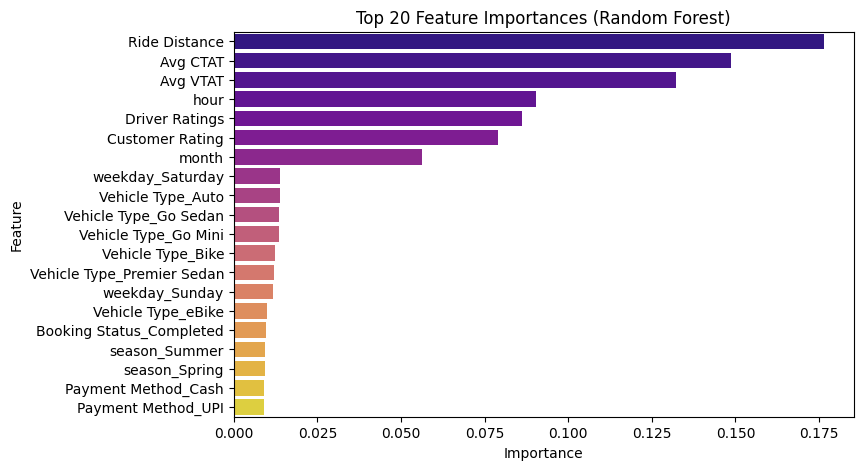

In [26]:
# Plotting feature importances
plt.figure(figsize=(8,5))
sns.barplot(data=feat_imp.head(20), x='Importance', y='Feature', palette='plasma')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.show()

The plot above shows the top 20 feature importances using Random Forest. The feature with the highest importance is `Ride Distance` with an approximate value of 0.18, followed by `Avg CTAT` and `Avg VTAT`. This seems valid as the distance of the ride should affect the price of the Uber fare. The time of day `hour` is also ranked 4th on importance as we saw earlier that the time of day has an effect on Uber ride demand and subsequently, the price of the booking fare. 

### Data Question 5: What differs between the top 1% and bottom 1% of Uber ride fares?

In [232]:
# Top 1% fares
q99 = df['Booking Value'].quantile(0.99)
top_1 = df[df['Booking Value'] > q99].copy()

# Bottom 1% fares
q1 = df['Booking Value'].quantile(0.01)
bottom_1 = df[df['Booking Value'] <= q1].copy()

# Combining both top and bottom 1%
combined_df = pd.concat([top_1, bottom_1])
combined_df['percentile'] = np.where(combined_df['Booking Value'] <= q1, 'Bottom 1%', 'Top 1%')

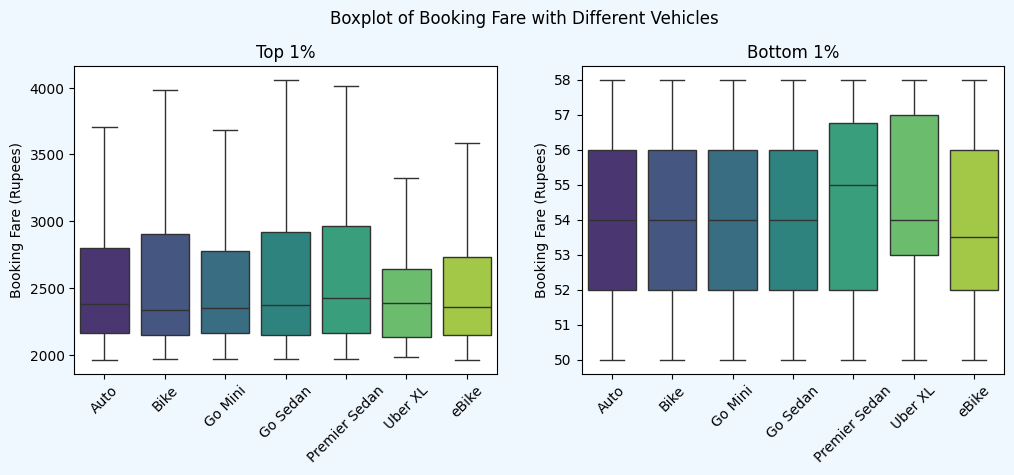

In [233]:
# Plotting boxplot 
plt.figure(figsize = (12,4), facecolor = 'aliceblue')
plt.suptitle('Boxplot of Booking Fare with Different Vehicles', y = 1.02)

# Top 1%
plt.subplot(1,2,1)
sns.boxplot(data = top_1, x = 'Vehicle Type', y = 'Booking Value', palette = 'viridis', showfliers = None)
plt.xticks(rotation = 45)
plt.xlabel('')
plt.ylabel('Booking Fare (Rupees)')
plt.title('Top 1%')

# Bottom 1%
plt.subplot(1,2,2)
sns.boxplot(data = bottom_1, x = 'Vehicle Type', y = 'Booking Value', palette = 'viridis', showfliers = None)
plt.xticks(rotation = 45)
plt.xlabel('')
plt.title('Bottom 1%')
plt.ylabel('Booking Fare (Rupees)')
plt.show()

The booking fare for the T1 (top 1%) of Uber rides is between 2000 and 4100 rupees whereas, the B1 (bottom 1%) is between 50 to 58 rupees. Premier Sedans have a higher upper quartile and the largest distribution in both the top and bottom 1%. For the T1, Uber XL seems to have the lowest upper quartile and the lowest distribution. This demonstrates that customers tend to avoid using Uber XL when travelling longer distances. For the B1, majority of the vehicle types have equal distribution except for Premier Sedans where it has the largest distribution. Go Sedans have the highest maximum booking fare while Uber XLs have the lowest.

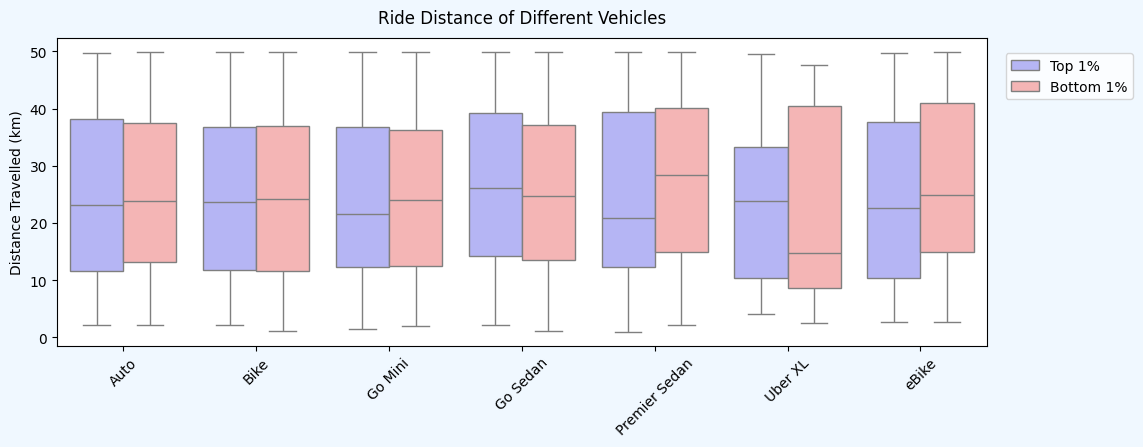

In [234]:
# Plotting boxplot of ride distance
plt.figure(figsize = (12,4), facecolor = 'aliceblue')
sns.boxplot(data = combined_df, x = 'Vehicle Type', y = 'Ride Distance', palette = 'bwr', showfliers = None, hue = 'percentile')
plt.title('Ride Distance of Different Vehicles', y = 1.02)
plt.xticks(rotation = 45)
plt.xlabel('')
plt.ylabel('Distance Travelled (km)')
plt.legend(loc= (1.02, 0.8))
plt.show()

The distance travelled for both top and bottom 1% is between the range of 1km to 50km. When comparing median distance travelled, the B1 tend to travel further for all vehicle types, especially in Premier Sedans. Only in Uber XLs do the T1 travel further in median. They also have a significantly larger distribution when travelling in Uber XLs. 

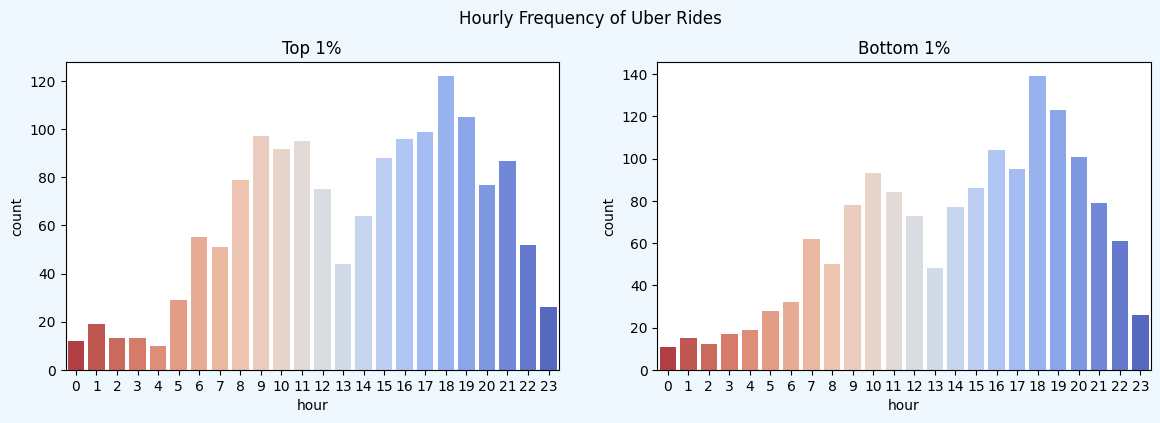

In [228]:
# Plotting frequency of uber rides
plt.figure(figsize = (14,4), facecolor = 'aliceblue')
plt.suptitle('Hourly Frequency of Uber Rides', y = 1.01)

# Top 1%
plt.subplot(1,2,1)
sns.countplot(data = top_10, x = 'hour', palette= 'coolwarm_r')
plt.title('Top 1%')
plt.ylabel('Frequency')

# Bottom 1%
plt.subplot(1,2,2)
sns.countplot(data = bottom_10, x = 'hour', palette= 'coolwarm_r')
plt.title('Bottom 1%')
plt.ylabel('Frequency')
plt.show()

Similarly, both of the top and bottom 1% have two peak hours however, they both differ in the morning. For the T1, it peaks around 8am whereas the B1 peaks around 10am. There is also a slight peak at 6am and 7am for T1 and B1 respectively. In the evening, both peak around 6pm. 

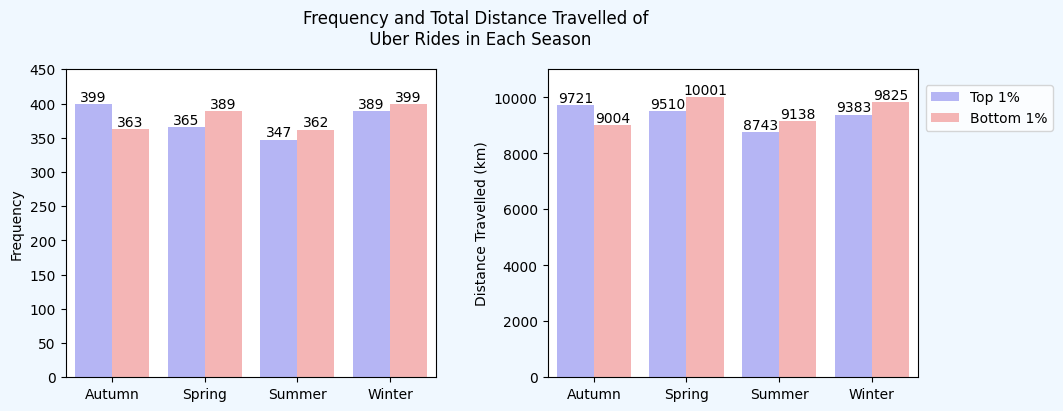

In [256]:
# # Plotting the grouped bar chart
plt.figure(figsize = (11, 4), facecolor = 'aliceblue')
plt.suptitle('Frequency and Total Distance Travelled of \n Uber Rides in Each Season', y = 1.03)
plt.subplots_adjust(wspace = 0.3)

# Frequency
plt.subplot(1,2,1)
ax = sns.countplot(data = combined_df, x = 'season', hue = 'percentile', palette = 'bwr', legend = False)
plt.ylabel('Frequency')
plt.xlabel('')
plt.ylim(0, 450) 
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt = '%1.0f')

# Distance travelled
plt.subplot(1,2,2)
ax = sns.barplot(data = combined_df, x = 'season', y = 'Ride Distance', hue = 'percentile', palette = 'bwr', ci =None, estimator = np.sum)
plt.ylabel('Distance Travelled (km)')
plt.legend(loc = (1.02,0.8))
plt.xlabel('')
plt.ylim(0, 11000)
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt = '%1.0f')
    
plt.show()

In terms of seasons, T1 only travels more during autumn while B1 travels travels more in the other seasons by a small percentage. 

## Conclusion

This project explores a dataset that contains information on Uber rides and identifies any trends or patterns. Data cleaning and feature engineering was performed to prepare our data before analysis. Firstly, we investigated various ride cancellations. It was found that 62% of Uber rides were successful while 18% of unsuccessful rides were cancelled by the driver. The remaining rides were cancelled by the customer, incomplete or a driver could not be found. Next, we found that certain months like January and March had higher frequencies in Uber rides while February had the lowest frequency. The number of Uber rides also peak at different times of the day; at 10am and 6pm. Weekends also seem to have a higher frequency of Uber rides than weekdays. It was also discovered that there was no significant difference in booking fare among different seasons of the year. In addition, majority of Uber rides (25%) used Automobiles, followed by Go Mini (20%) and Go Sedan (18%). However, the distance travelled by each vehicle type is approximately the same. Other than that, the distance of the Uber ride has the largest correlation with the booking fare. The ride duration and pickup duration (time to reach pickup location) also had a large effect on the booking fare in comparison to the rest. We also compared the top and bottom 1% of Uber rides. It was found that Premier Sedans have the largest distribution for both T1 and B1 while Go Sedans have the highest maximum booking fare for T1 customers. The peak hours for T1 and B1 also differ slightly in the morning; 8am for T1 and 10am for B1. There were more customers in autumn for T1 customers while B1 customers travelled more in the other seasons. 